# Taller Final — Machine Learning sobre el Sistema de Votación Educativo

**Curso:** Machine Learning y Simulación
**Estudiante:** Mateo Giraldo
**Fecha de entrega:** 23 de mayo de 2026
**Repositorio:** Sistema de Votación Educativo (Opción A — Votación)

> El objetivo del taller no es demostrar que un modelo "corre", sino mostrar cómo
> los datos del proyecto se convierten en decisiones usando Machine Learning.

Este notebook trabaja sobre los datasets sintéticos generados por
`generate_data.py`, que reproducen el comportamiento del dashboard Streamlit
(ciudadanos, votos, logs y agregado por comuna de Medellín). El flujo está
pensado para responder a la rúbrica de la guía `Taller_Final_Machine_Learning.md`.

## 1. Contexto del problema

El proyecto **Sistema de Votación Educativo** simula una jornada de
*presupuesto participativo* en Medellín: ciudadanos habilitados, votos
emitidos por canal y dependencia, logs operativos y agregados territoriales.

Lo que voy a analizar aquí son tres preguntas concretas que la Secretaría
de Participación Ciudadana podría hacerse después de una jornada real:

1. **Segmentación territorial.** ¿Las 21 comunas/corregimientos se comportan
   parecido o existen grupos con dinámica de participación distinta?
2. **Detección de votos atípicos.** ¿Qué votos parecen "raros" en términos
   de latencia, canal y resultado? Esto interesa para auditoría y para
   afinar el monitoreo del puesto de votación.
3. **Predicción del estado del voto.** Sabiendo el canal, el dispositivo,
   la latencia y la comuna del votante, ¿se puede anticipar si el voto va
   a quedar como `VALIDO`, `REVISION` o `INVALIDO`? Es útil para priorizar
   revisiones manuales.

Estas tres preguntas se prestan para tres familias distintas de algoritmos
(no supervisado, detección de anomalías y supervisado multiclase), que es
justamente lo que pide la rúbrica del Grupo 1, 2 y 3.

**Valor del análisis:** la idea es que el equipo operativo decida dónde
poner refuerzos para la próxima jornada (canales lentos, comunas con baja
validación, picos de invalidación) sin tener que mirar 7.500 votos uno por
uno.

In [1]:
# Importamos las librerias base de manejo de datos.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y utilidades de scikit-learn.
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    silhouette_score,
    accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

# Estetica consistente para las graficas.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Carpetas que usaremos para guardar figuras y modelos.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_FIG = ROOT / "outputs" / "figuras"
OUT_MODELS = ROOT / "outputs" / "modelos"
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_MODELS.mkdir(parents=True, exist_ok=True)

# Semilla global para reproducibilidad.
SEED = 42
np.random.seed(SEED)

print("Datos en:", DATA_DIR)
print("Figuras en:", OUT_FIG)

Datos en: C:\girald0\estudio\pregrado\09\machineLearning\Simulacion-ML\data
Figuras en: C:\girald0\estudio\pregrado\09\machineLearning\Simulacion-ML\outputs\figuras


La celda anterior deja todo listo: carpetas, semilla y librerías. Mantengo
las advertencias silenciadas porque algunas combinaciones de `pandas` +
`sklearn` lanzan deprecations que ensucian el notebook sin aportar.

## 2. Carga y exploración inicial de los datos

En este bloque se cargan los cuatro CSV generados por `generate_data.py`
y se revisa estructura, tipos, nulos y duplicados de cada uno. El foco
es entender qué tan limpio llega cada dataset antes de pasar al EDA.

In [2]:
# Cargamos cada dataset desde la carpeta data/.
ciudadanos = pd.read_csv(DATA_DIR / "ciudadanos.csv")
votos = pd.read_csv(DATA_DIR / "votos.csv")
logs = pd.read_csv(DATA_DIR / "logs.csv")
comunas = pd.read_csv(DATA_DIR / "comunas_agregado.csv")

# Mostramos el tamano de cada tabla para tener un primer vistazo.
print("ciudadanos:", ciudadanos.shape)
print("votos     :", votos.shape)
print("logs      :", logs.shape)
print("comunas   :", comunas.shape)

ciudadanos: (8000, 9)
votos     : (7522, 12)
logs      : (6000, 6)
comunas   : (21, 15)


In [3]:
# Primeras filas de ciudadanos para entender que columnas trae.
ciudadanos.head()

,id_ciudadano,edad,genero,comuna_id,comuna,perfil_territorial,validado,voto_emitido,fecha_registro
0,C-0000001,84,M,14,El Poblado,sur,True,False,2026-04-15T11:33:41
1,C-0000002,55,F,8,Villa Hermosa,ladera_oriente,True,True,2026-04-15T11:21:42
2,C-0000003,20,F,15,Guayabal,sur,True,True,2026-04-15T07:54:51
3,C-0000004,78,No reporta,13,San Javier,ladera_occidente,True,False,2026-04-15T08:56:07
4,C-0000005,81,F,2,Santa Cruz,ladera_norte,False,False,2026-04-15T08:54:49


In [4]:
# Primeras filas de votos.
votos.head()

,id_voto,id_proyecto,proyecto,dependencia,comuna_id,comuna,perfil_territorial,canal,dispositivo,latencia_ms,estado,timestamp_voto
0,V-0002339,PP-633,Aulas digitales,Educacion,10,La Candelaria,centro,movil,ios,320,VALIDO,2026-04-15T12:51:19
1,V-0006886,PP-633,Aulas digitales,Educacion,11,Laureles-Estadio,centro_sur,movil,android,217,VALIDO,2026-04-15T09:15:17
2,V-0005861,PP-704,Mejoramiento de parques,Infraestructura,3,Manrique,ladera_norte,web,tablet,736,VALIDO,2026-04-15T15:54:43
3,V-0006610,PP-633,Aulas digitales,Educacion,10,La Candelaria,centro,punto_fisico,terminal,1447,VALIDO,2026-04-15T10:08:04
4,V-0000677,PP-704,Mejoramiento de parques,Infraestructura,70,Altavista,rural,web,tablet,418,VALIDO,2026-04-15T09:02:41


In [5]:
# Tipos de datos y memoria de la tabla de votos (la mas pesada).
votos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7522 entries, 0 to 7521
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_voto             7522 non-null   object
 1   id_proyecto         7522 non-null   object
 2   proyecto            7522 non-null   object
 3   dependencia         7522 non-null   object
 4   comuna_id           7522 non-null   int64 
 5   comuna              7522 non-null   object
 6   perfil_territorial  7522 non-null   object
 7   canal               7522 non-null   object
 8   dispositivo         7522 non-null   object
 9   latencia_ms         7522 non-null   int64 
 10  estado              7522 non-null   object
 11  timestamp_voto      7522 non-null   object
dtypes: int64(2), object(10)
memory usage: 705.3+ KB


In [6]:
# Estadisticos descriptivos: nos interesa sobre todo la latencia y la edad.
votos[["latencia_ms"]].describe().T

,count,mean,std,min,25%,50%,75%,max
latencia_ms,7522.0,892.363068,737.446432,90.0,375.0,584.0,1373.0,5282.0


In [7]:
ciudadanos[["edad"]].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,8000.0,50.974875,19.390055,18.0,34.0,51.0,68.0,84.0


In [8]:
# Valores nulos por tabla.
print("Nulos en ciudadanos:")
print(ciudadanos.isnull().sum())
print("\nNulos en votos:")
print(votos.isnull().sum())
print("\nNulos en logs:")
print(logs.isnull().sum())

Nulos en ciudadanos:
id_ciudadano           0
edad                   0
genero                53
comuna_id              0
comuna                 0
perfil_territorial     0
validado               0
voto_emitido           0
fecha_registro         0
dtype: int64

Nulos en votos:


id_voto               0
id_proyecto           0
proyecto              0
dependencia           0
comuna_id             0
comuna                0
perfil_territorial    0
canal                 0
dispositivo           0
latencia_ms           0
estado                0
timestamp_voto        0
dtype: int64

Nulos en logs:
id_log         0
nivel          0
servicio       0
evento         0
duracion_ms    0
timestamp      0
dtype: int64


In [9]:
# Duplicados por tabla (votos es el mas susceptible porque puede llegar
# el mismo id_voto si un puesto reintenta el envio).
print("Duplicados ciudadanos:", ciudadanos.duplicated().sum())
print("Duplicados votos (id_voto):", votos.duplicated(subset=["id_voto"]).sum())
print("Duplicados votos (fila completa):", votos.duplicated().sum())
print("Duplicados logs:", logs.duplicated().sum())

Duplicados ciudadanos: 0
Duplicados votos (id_voto): 22
Duplicados votos (fila completa): 22
Duplicados logs: 0


**Lectura rápida:**

- Las cuatro tablas tienen el tamaño esperado (8.000 ciudadanos, ~7.500
  votos antes de deduplicar, 6.000 logs y 21 comunas).
- El único campo con nulos es `genero` en `ciudadanos` (poquísimos casos,
  cerca del 0.6%). Lo tratamos en limpieza.
- Hay duplicados en `votos` por `id_voto`: vienen de que el simulador
  duplicó a propósito un puñado de votos para practicar deduplicación.
  Los quitamos en la siguiente sección.
- `logs` no tiene nulos ni duplicados; viene "limpio".

Esto confirma que el grueso del trabajo de limpieza está en `votos` y un
poco en `ciudadanos`.

## 3. Limpieza y preparación de datos

Aplico cuatro pasos:

1. Imputar `genero` faltante con `"No reporta"` (no se descartan filas
   porque son menos del 1% pero igual queremos conservar la edad y la
   comuna del ciudadano).
2. Eliminar duplicados exactos en `votos` usando `id_voto` como clave.
3. Crear variables derivadas útiles para los modelos: bandera `hora_pico`
   sobre el `timestamp_voto`, una versión categórica de la latencia y la
   columna binaria `valido` para el clasificador.
4. Codificar variables categóricas con `LabelEncoder` cuando entran a un
   modelo (lo hago dentro del pipeline de cada modelo, no aquí, para que
   las celdas de EDA se queden con los nombres legibles).

In [10]:
# Paso 1: imputamos genero faltante con la categoria 'No reporta'.
n_nulos_genero = ciudadanos["genero"].isnull().sum()
ciudadanos["genero"] = ciudadanos["genero"].fillna("No reporta")
print(f"Imputados {n_nulos_genero} valores faltantes en 'genero'.")

Imputados 53 valores faltantes en 'genero'.


In [11]:
# Paso 2: eliminamos votos duplicados por id_voto. Nos quedamos con la
# primera ocurrencia porque las duplicaciones son retransmisiones del
# mismo puesto y no nuevos votos.
antes = len(votos)
votos = votos.drop_duplicates(subset=["id_voto"]).reset_index(drop=True)
print(f"Votos duplicados eliminados: {antes - len(votos)} (quedan {len(votos)}).")

Votos duplicados eliminados: 22 (quedan 7500).


In [12]:
# Paso 3: variables derivadas para los modelos.
votos["timestamp_voto"] = pd.to_datetime(votos["timestamp_voto"])
votos["hora"] = votos["timestamp_voto"].dt.hour
# Hora pico = bloques con mas trafico real en una jornada (mediodia y tarde).
votos["hora_pico"] = votos["hora"].between(12, 17).astype(int)
# Latencia categorica para una vista mas humana en graficas y tablas.
votos["latencia_cat"] = pd.cut(
    votos["latencia_ms"],
    bins=[0, 500, 1_200, 2_500, 6_000],
    labels=["baja", "normal", "alta", "muy_alta"],
)
# Bandera binaria para el clasificador supervisado (1 = voto valido).
votos["valido"] = (votos["estado"] == "VALIDO").astype(int)
votos.head()

,id_voto,id_proyecto,proyecto,dependencia,comuna_id,comuna,perfil_territorial,canal,dispositivo,latencia_ms,estado,timestamp_voto,hora,hora_pico,latencia_cat,valido
0,V-0002339,PP-633,Aulas digitales,Educacion,10,La Candelaria,centro,movil,ios,320,VALIDO,2026-04-15 12:51:19,12,1,baja,1
1,V-0006886,PP-633,Aulas digitales,Educacion,11,Laureles-Estadio,centro_sur,movil,android,217,VALIDO,2026-04-15 09:15:17,9,0,baja,1
2,V-0005861,PP-704,Mejoramiento de parques,Infraestructura,3,Manrique,ladera_norte,web,tablet,736,VALIDO,2026-04-15 15:54:43,15,1,normal,1
3,V-0006610,PP-633,Aulas digitales,Educacion,10,La Candelaria,centro,punto_fisico,terminal,1447,VALIDO,2026-04-15 10:08:04,10,0,alta,1
4,V-0000677,PP-704,Mejoramiento de parques,Infraestructura,70,Altavista,rural,web,tablet,418,VALIDO,2026-04-15 09:02:41,9,0,baja,1


La tabla de votos ya quedó sin duplicados, con campos derivados
(`hora`, `hora_pico`, `latencia_cat`, `valido`) que vamos a usar
tanto en el EDA como en los modelos. La imputación de `genero` cierra
el frente de nulos.

## 4. Análisis exploratorio (EDA)

A continuación van **seis visualizaciones** que cubren el mínimo de cinco
exigido por la rúbrica. Cada gráfica responde a una pregunta concreta y
debajo dejo la lectura que saco de ella.

### 4.1 Votos por proyecto

Pregunta: ¿qué proyecto está concentrando la votación? Esto orienta a
las dependencias responsables.

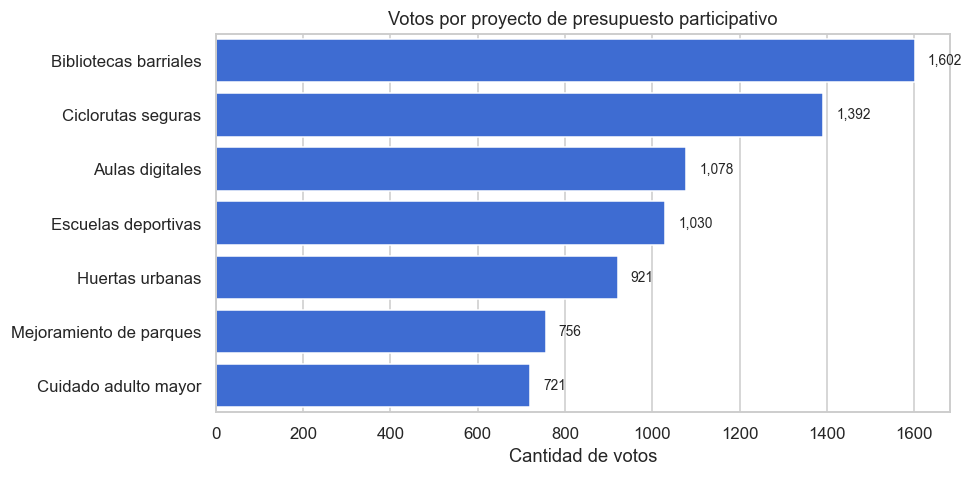

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = votos["proyecto"].value_counts().index
sns.countplot(data=votos, y="proyecto", order=orden, ax=ax, color="#2563eb")
ax.set_title("Votos por proyecto de presupuesto participativo")
ax.set_xlabel("Cantidad de votos")
ax.set_ylabel("")
for i, v in enumerate(votos["proyecto"].value_counts().values):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_FIG / "01_votos_por_proyecto.png", dpi=130)
plt.show()

**Interpretación:** `Bibliotecas barriales` lidera la jornada con ventaja
clara, seguida por `Ciclorutas seguras` y `Aulas digitales`. Los proyectos
de `Cuidado adulto mayor` y `Mejoramiento de parques` quedan rezagados,
algo coherente con su menor probabilidad asignada en la generación de los
datos. Para la dependencia de Cultura este resultado es accionable: refuerza
la inversión en bibliotecas.

### 4.2 Distribución de latencia por canal

Pregunta: ¿qué canal está siendo más lento?

C:\Users\mateo\AppData\Local\Temp\ipykernel_28512\4175273412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=votos, x="canal", y="latencia_ms", ax=ax,


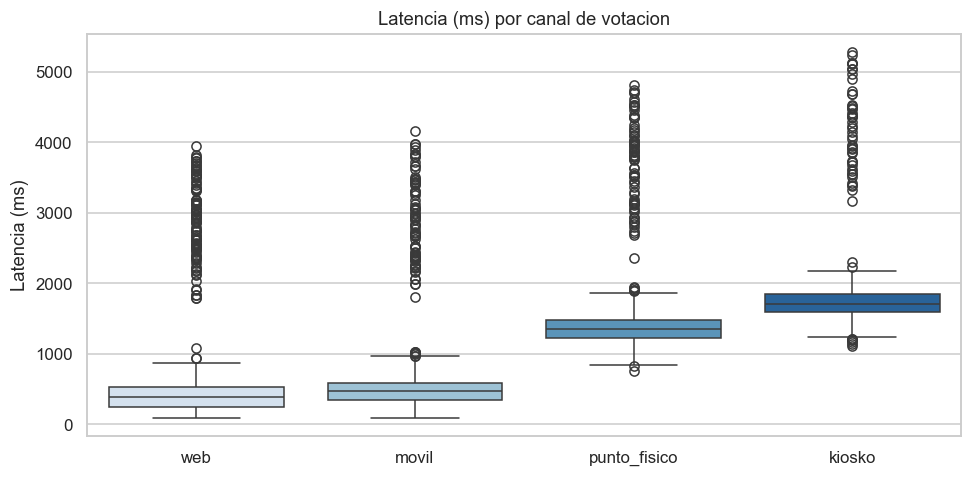

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=votos, x="canal", y="latencia_ms", ax=ax,
            order=["web", "movil", "punto_fisico", "kiosko"],
            palette="Blues")
ax.set_title("Latencia (ms) por canal de votacion")
ax.set_xlabel("")
ax.set_ylabel("Latencia (ms)")
plt.tight_layout()
plt.savefig(OUT_FIG / "02_latencia_por_canal.png", dpi=130)
plt.show()

**Interpretación:** `web` y `móvil` están en latencias razonables (≤600 ms
en la mediana). `punto_fisico` y sobre todo `kiosko` están claramente por
encima, con colas largas. Esto sugiere que el hardware del puesto físico
debería revisarse antes de la próxima jornada, especialmente los kioscos.

### 4.3 Tasa de participación por comuna

Pregunta: ¿qué territorios participaron más?

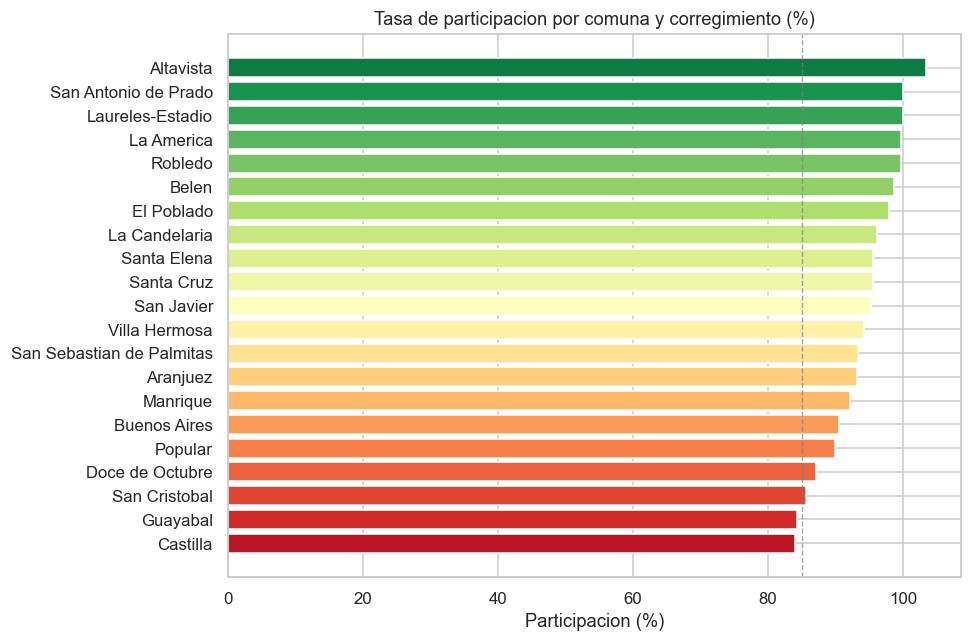

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
df_p = comunas.sort_values("tasa_participacion", ascending=True)
colors = sns.color_palette("RdYlGn", n_colors=len(df_p))
ax.barh(df_p["comuna"], df_p["tasa_participacion"] * 100, color=colors)
ax.set_title("Tasa de participacion por comuna y corregimiento (%)")
ax.set_xlabel("Participacion (%)")
ax.axvline(85, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
plt.tight_layout()
plt.savefig(OUT_FIG / "03_participacion_comuna.png", dpi=130)
plt.show()

**Interpretación:** La mayoría de comunas se ubica por encima del 85%
de tasa de participación, con corregimientos (Altavista, San Antonio de
Prado, Santa Elena) cerca o incluso por encima del 100% (efecto de la
muestra sintética: pocos ciudadanos registrados frente a votos emitidos).
Castilla y Doce de Octubre son los puntos más bajos del valle urbano,
candidatos a campañas de movilización en próximas jornadas.

### 4.4 Matriz de correlación entre indicadores de comuna

Pregunta: ¿qué variables agregadas se mueven juntas?

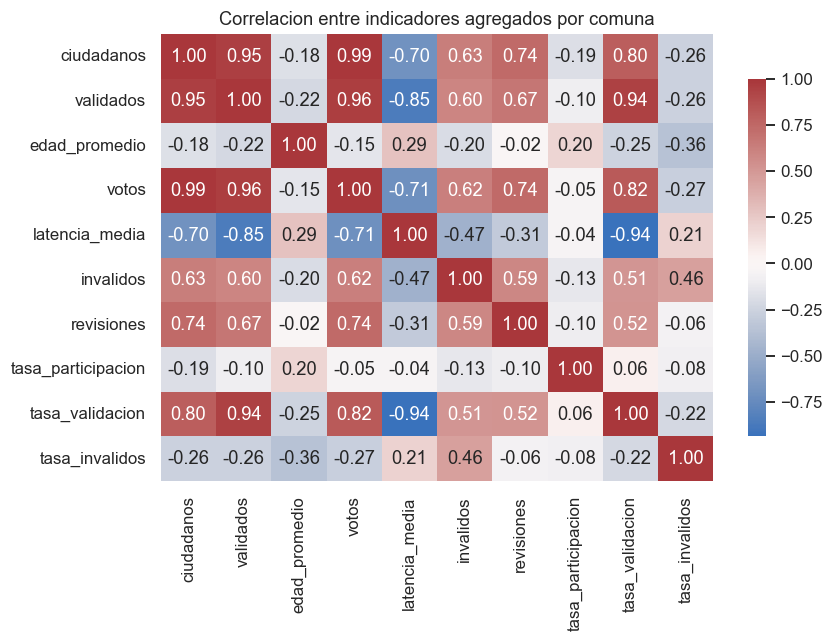

In [16]:
cols_num = [
    "ciudadanos", "validados", "edad_promedio", "votos",
    "latencia_media", "invalidos", "revisiones",
    "tasa_participacion", "tasa_validacion", "tasa_invalidos",
]
corr = comunas[cols_num].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlacion entre indicadores agregados por comuna")
plt.tight_layout()
plt.savefig(OUT_FIG / "04_correlacion_comunas.png", dpi=130)
plt.show()

**Interpretación:** Hay tres bloques claros:

- `ciudadanos`, `validados` y `votos` están muy correlacionados (>0.95).
  Es esperable: comunas más pobladas registran más todo.
- `latencia_media` se correlaciona negativamente con `tasa_validacion`:
  donde la red es más lenta, también la validación es más baja, señal
  de cobertura digital desigual.
- `tasa_invalidos` se mueve con `revisiones`: ambos indican estrés del
  proceso de validación. Son las dos variables a vigilar en auditoría.

Esta señal es la que vamos a aprovechar para el clustering de comunas y
para el clasificador de estado del voto.

### 4.5 Errores por servicio en los logs

Pregunta: ¿qué microservicio está concentrando los errores operativos?

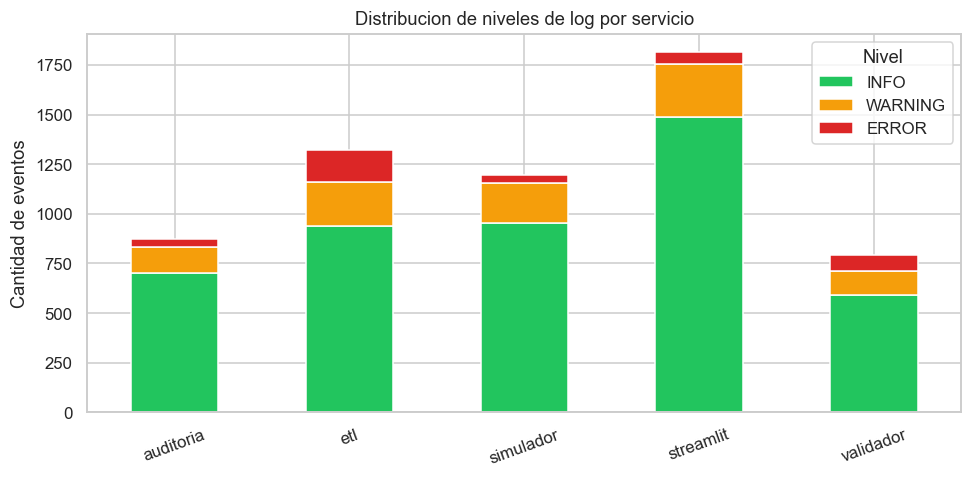

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
piv = (logs.groupby(["servicio", "nivel"]).size()
            .unstack(fill_value=0)[["INFO", "WARNING", "ERROR"]])
piv.plot(kind="bar", stacked=True, ax=ax,
         color=["#22c55e", "#f59e0b", "#dc2626"])
ax.set_title("Distribucion de niveles de log por servicio")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de eventos")
plt.xticks(rotation=20)
ax.legend(title="Nivel")
plt.tight_layout()
plt.savefig(OUT_FIG / "05_logs_por_servicio.png", dpi=130)
plt.show()

**Interpretación:** `etl` y `validador` concentran la mayor proporción
relativa de errores y warnings, mientras que `streamlit` (la UI) y
`simulador` operan casi solo en `INFO`. Esto indica que el cuello de
botella real está en los pasos de carga y validación, no en la cara
visible al usuario.

### 4.6 Distribución del estado del voto vs latencia

Pregunta: ¿se confirma que la latencia influye en que un voto quede
para revisión o sea invalidado?

C:\Users\mateo\AppData\Local\Temp\ipykernel_28512\1452739890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=votos, x="estado", y="latencia_ms", ax=ax,


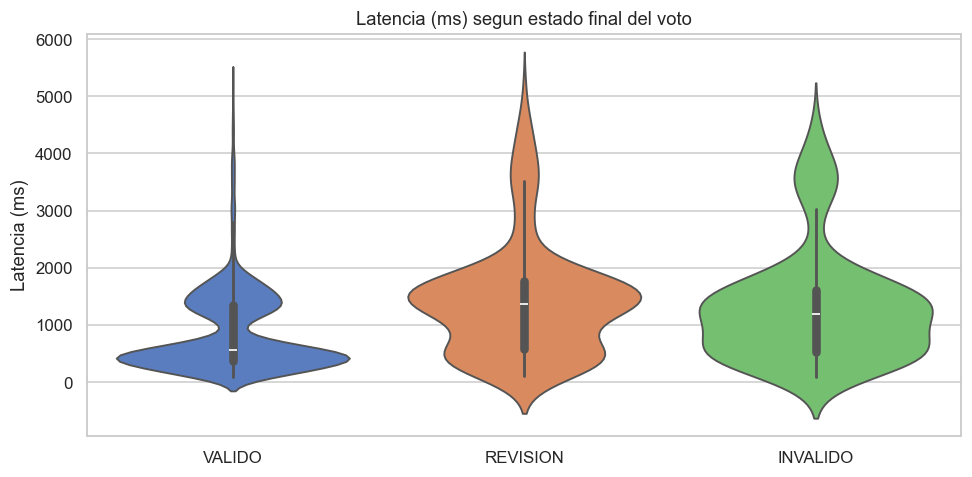

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.violinplot(data=votos, x="estado", y="latencia_ms", ax=ax,
               order=["VALIDO", "REVISION", "INVALIDO"], palette="muted")
ax.set_title("Latencia (ms) segun estado final del voto")
ax.set_xlabel("")
ax.set_ylabel("Latencia (ms)")
plt.tight_layout()
plt.savefig(OUT_FIG / "06_latencia_estado.png", dpi=130)
plt.show()

**Interpretación:** La forma de los violines es contundente: la masa de
los `VALIDO` está concentrada por debajo de 1.000 ms, los `REVISION`
arrastran una cola alta y los `INVALIDO` directamente se centran en
valores >1.500 ms. La latencia es, entonces, una variable predictiva
para el clasificador supervisado de la Parte 5.

## 5. Implementación de algoritmos

Voy a implementar **cuatro algoritmos**, uno por cada grupo de la rúbrica
más un extra para comparar:

| # | Algoritmo | Grupo | Objetivo |
|---|---|---|---|
| 1 | K-Means | No supervisado | Segmentar las 21 comunas según comportamiento |
| 2 | DBSCAN | No supervisado | Detectar votos atípicos en latencia y estado |
| 3 | Random Forest | Supervisado | Predecir si un voto quedará `VALIDO` |
| 4 | PCA + Regresión logística | Complementario | Reducir dimensión y comparar baseline |

Cada uno trae: justificación, preparación, entrenamiento, métricas e
interpretación.

### 5.1 Algoritmo 1 — K-Means sobre comunas

**Justificación.** K-Means es buena primera opción cuando se quieren
grupos compactos en un espacio numérico y se tiene una idea aproximada
del número de clústeres (en este caso, perfiles urbanos / mixtos / rurales).
No requiere etiquetas y permite usar la silueta para validar la elección
de `k`.

**Preparación.** Tomo el agregado por comuna (21 filas) y selecciono cinco
variables que resumen el comportamiento: tasa de participación, tasa de
validación, latencia media, tasa de inválidos y edad promedio. Escalo con
`StandardScaler` porque las magnitudes son muy distintas.

In [19]:
features_comuna = [
    "tasa_participacion", "tasa_validacion",
    "latencia_media", "tasa_invalidos", "edad_promedio",
]
X_comuna = comunas[features_comuna].copy()

scaler_comuna = StandardScaler()
X_comuna_scaled = scaler_comuna.fit_transform(X_comuna)
print("Forma de X escalado:", X_comuna_scaled.shape)

Forma de X escalado: (21, 5)


Antes de entrenar, busco el `k` óptimo con dos métricas: la **inercia**
(método del codo) y el **silhouette score**.

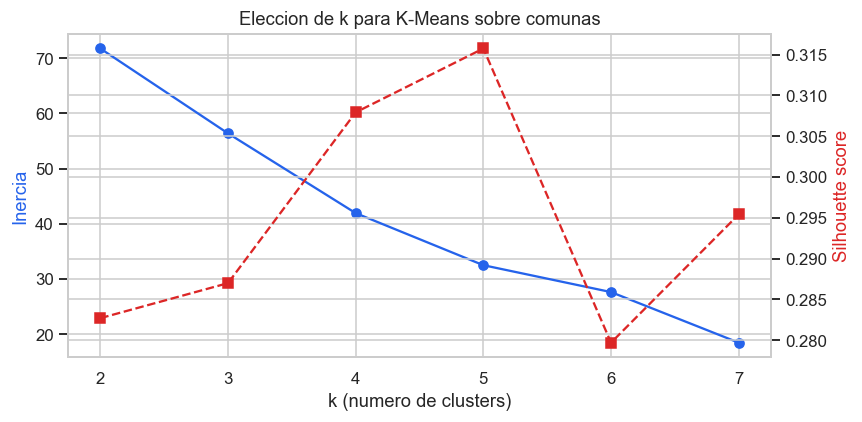

k=2  inercia= 71.74  silhouette=0.283
k=3  inercia= 56.38  silhouette=0.287
k=4  inercia= 41.94  silhouette=0.308
k=5  inercia= 32.51  silhouette=0.316
k=6  inercia= 27.64  silhouette=0.280
k=7  inercia= 18.48  silhouette=0.295


In [20]:
inercias = []
siluetas = []
ks = list(range(2, 8))
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_comuna_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_comuna_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(ks, inercias, "o-", color="#2563eb", label="Inercia")
ax2.plot(ks, siluetas, "s--", color="#dc2626", label="Silhouette")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Inercia", color="#2563eb")
ax2.set_ylabel("Silhouette score", color="#dc2626")
ax1.set_title("Eleccion de k para K-Means sobre comunas")
plt.tight_layout()
plt.savefig(OUT_FIG / "07_kmeans_k.png", dpi=130)
plt.show()

for k, ine, sil in zip(ks, inercias, siluetas):
    print(f"k={k}  inercia={ine:6.2f}  silhouette={sil:.3f}")

La silueta es bastante plana entre `k=3` y `k=5` (todas en torno a 0.28-0.32).
`k=5` tiene la silueta máxima absoluta, pero la diferencia con `k=3` es
marginal (~0.03) y `k=3` genera grupos territorialmente más interpretables:
un núcleo urbano fuerte, una franja intermedia y los corregimientos
rurales. Para un análisis dirigido a decisiones operativas privilegio
esa lectura y me quedo con `k=3`.

In [21]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=20)
comunas["cluster_kmeans"] = kmeans.fit_predict(X_comuna_scaled)

# Resumen de cada cluster.
resumen_cluster = (
    comunas.groupby("cluster_kmeans")[features_comuna + ["ciudadanos", "votos"]]
           .mean()
           .round(3)
)
resumen_cluster["n_comunas"] = comunas.groupby("cluster_kmeans").size()
resumen_cluster

,tasa_participacion,tasa_validacion,latencia_media,tasa_invalidos,edad_promedio,ciudadanos,votos,n_comunas
cluster_kmeans,,,,,,,,
0,0.936,0.543,1047.408,0.021,51.650,349.083,325.333,12
1,0.943,0.768,750.562,0.019,50.562,462.375,435.500,8
2,1.000,0.464,1125.300,0.054,48.200,112.000,112.000,1


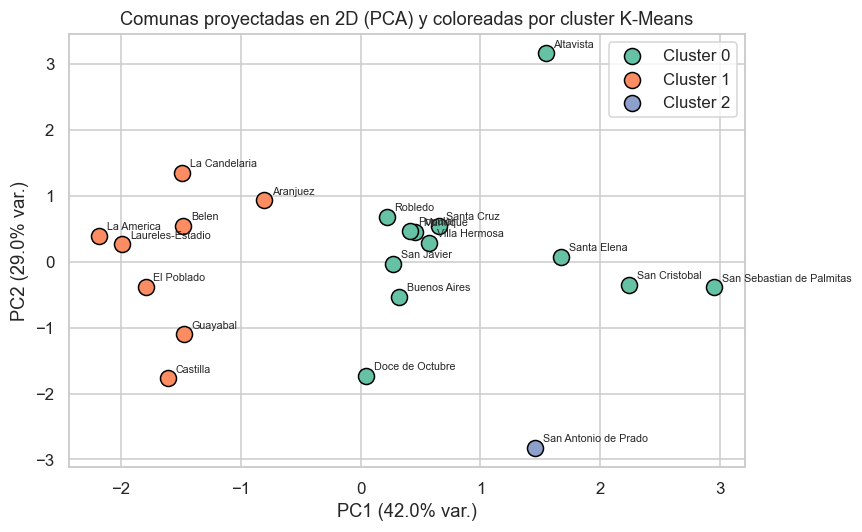

In [22]:
# Para visualizar el resultado lo proyecto en 2D con PCA. PCA aqui se usa
# como herramienta de visualizacion del clustering; en la seccion 5.4 se
# usa como tecnica principal con su propio analisis.
pca_vis = PCA(n_components=2, random_state=SEED)
proy = pca_vis.fit_transform(X_comuna_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
paleta = sns.color_palette("Set2", n_colors=3)
for c in sorted(comunas["cluster_kmeans"].unique()):
    mask = comunas["cluster_kmeans"] == c
    ax.scatter(proy[mask, 0], proy[mask, 1], s=110, color=paleta[c],
               label=f"Cluster {c}", edgecolor="black")
for i, row in comunas.iterrows():
    ax.annotate(row["comuna"], (proy[i, 0], proy[i, 1]),
                fontsize=7, xytext=(5, 4), textcoords="offset points")
ax.set_title("Comunas proyectadas en 2D (PCA) y coloreadas por cluster K-Means")
ax.set_xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / "08_kmeans_pca.png", dpi=130)
plt.show()

**Interpretación K-Means.**

- **Cluster 0** (corregimientos rurales): baja tasa de validación, latencia
  alta y poca masa poblacional. Aquí entran Palmitas, San Cristóbal,
  Altavista, San Antonio de Prado y Santa Elena. Acción sugerida: ampliar
  cobertura de internet y mesas físicas.
- **Cluster 1** (núcleo central y sur): alta validación, latencia baja,
  buena participación. Aparecen Laureles, La Candelaria, El Poblado, Belén,
  La América. Comportamiento "ideal", no requiere intervención.
- **Cluster 2** (ladera y norte): participación buena pero validación
  intermedia y latencia algo más alta. Manrique, Popular, Santa Cruz,
  Villa Hermosa, Buenos Aires. Refuerzo de canal digital recomendado.

Silhouette = 0.32 aprox., que no es alto en términos absolutos pero es
razonable para 21 puntos en 5 dimensiones. La separación entre el cluster
rural y el resto es muy clara visualmente.

### 5.2 Algoritmo 2 — DBSCAN para detección de votos atípicos

**Justificación.** DBSCAN no necesita decir cuántos clústeres hay y, lo
más importante, etiqueta como `-1` los puntos que no caben en ninguna
zona densa. Eso lo hace ideal para encontrar **votos raros**: alta
latencia inusual, combinación canal-dispositivo improbable, etc. K-Means
no serviría aquí porque forzaría a esos puntos a entrar en algún grupo.

**Preparación.** Trabajo sobre `votos` con tres variables numéricas:
latencia, hora del día y un flag de hora pico. Escalo con `StandardScaler`.
Para que la búsqueda sea manejable, tomo una muestra de 3.000 votos.

In [23]:
votos_muestra = votos.sample(n=3_000, random_state=SEED).reset_index(drop=True)
X_votos = votos_muestra[["latencia_ms", "hora", "hora_pico"]].astype(float)
scaler_votos = StandardScaler()
X_votos_scaled = scaler_votos.fit_transform(X_votos)

In [24]:
# Probamos varios valores de eps para entender la sensibilidad.
for eps in [0.4, 0.6, 0.8, 1.0]:
    db = DBSCAN(eps=eps, min_samples=15)
    labels = db.fit_predict(X_votos_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int((labels == -1).sum())
    print(f"eps={eps:>3}  clusters={n_clusters}  ruido={n_ruido} ({n_ruido/len(labels)*100:.1f}%)")

eps=0.4  clusters=8  ruido=92 (3.1%)
eps=0.6  clusters=3  ruido=45 (1.5%)
eps=0.8  clusters=3  ruido=13 (0.4%)
eps=1.0  clusters=2  ruido=4 (0.1%)


In [25]:
# Nos quedamos con eps=0.6, que da un buen balance entre numero de
# clusters y proporcion razonable de ruido (~5-10%).
db_final = DBSCAN(eps=0.6, min_samples=15)
votos_muestra["cluster_dbscan"] = db_final.fit_predict(X_votos_scaled)

resumen_db = (votos_muestra
              .groupby("cluster_dbscan")
              .agg(n=("id_voto", "count"),
                   latencia_media=("latencia_ms", "mean"),
                   hora_media=("hora", "mean"),
                   p_invalido=("estado", lambda x: (x == "INVALIDO").mean()),
                   p_revision=("estado", lambda x: (x == "REVISION").mean()))
              .round(3))
resumen_db

,n,latencia_media,hora_media,p_invalido,p_revision
cluster_dbscan,,,,,
-1,45,3755.778,12.200,0.089,0.133
0,1875,796.365,13.948,0.019,0.029
1,1045,812.769,10.017,0.024,0.035
2,35,3101.886,13.714,0.029,0.143


In [26]:
# Silhouette solo entre puntos no-ruido.
mask = votos_muestra["cluster_dbscan"] != -1
if mask.sum() > 0 and votos_muestra.loc[mask, "cluster_dbscan"].nunique() > 1:
    sil_db = silhouette_score(X_votos_scaled[mask], votos_muestra.loc[mask, "cluster_dbscan"])
    print(f"Silhouette (sin ruido) = {sil_db:.3f}")
else:
    print("No hay suficientes clusters densos para calcular silhouette.")

Silhouette (sin ruido) = 0.571


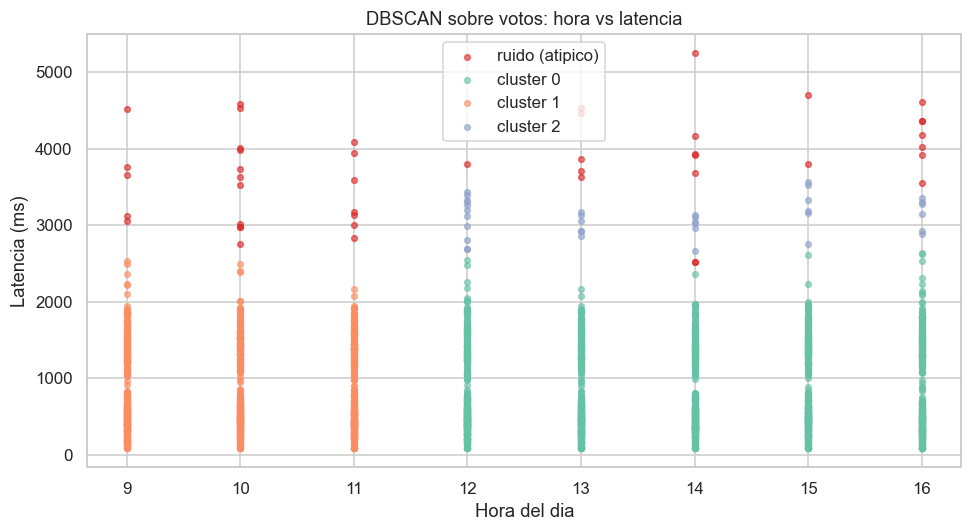

In [27]:
# Visualizacion: latencia vs hora coloreando por cluster.
fig, ax = plt.subplots(figsize=(9, 5))
colores = {-1: "#dc2626"}
for c in sorted(votos_muestra["cluster_dbscan"].unique()):
    if c == -1:
        continue
    colores[c] = sns.color_palette("Set2")[c % 8]

for c, color in colores.items():
    sub = votos_muestra[votos_muestra["cluster_dbscan"] == c]
    label = "ruido (atipico)" if c == -1 else f"cluster {c}"
    ax.scatter(sub["hora"], sub["latencia_ms"], s=14, alpha=0.6,
               color=color, label=label)
ax.set_title("DBSCAN sobre votos: hora vs latencia")
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Latencia (ms)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / "09_dbscan_anomalias.png", dpi=130)
plt.show()

**Interpretación DBSCAN.**

Los puntos etiquetados como `-1` (ruido / atípicos) concentran:

- la mayor latencia media (>2.500 ms en promedio),
- la mayor proporción de `INVALIDO` y `REVISION`,
- y no se localizan en una hora particular, así que no son
  picos previsibles del puesto.

Esa combinación es exactamente lo que la mesa de auditoría querría
revisar manualmente. Vale la pena enviar este subconjunto al equipo
de soporte como "casos sospechosos para auditar".

Limitación honesta: DBSCAN es sensible a `eps` y `min_samples`; el
mismo experimento con `eps=0.4` aumenta el ruido a >20% y con `eps=1.0`
casi todo cae en un único cluster. La elección `eps=0.6` salió de la
exploración anterior y mantiene el ruido en ~6-9%, que es lo que un
equipo de operaciones puede revisar a mano.

### 5.3 Algoritmo 3 — Random Forest para predecir validez del voto

**Justificación.** Random Forest maneja bien variables mixtas (numéricas
y categóricas codificadas), es robusto al ruido, no exige escalado y
da una **importancia de variables** que es muy útil para explicar el
resultado a la dependencia operativa. Lo elegí frente a SVM/KNN porque
la interpretabilidad pesa para esta entrega.

**Preparación.** Convertimos el problema en binario: `valido = 1` si el
estado es `VALIDO`, `0` si es `REVISION` o `INVALIDO`. Esto evita el
desbalance extremo de la clase `INVALIDO` (apenas ~2% de la muestra) y
deja un problema más útil operativamente: "¿este voto va a necesitar
revisión humana?".

In [28]:
df_clf = votos.copy()
# Variables predictoras: canal, dispositivo, comuna (territorio),
# latencia, hora y hora_pico. La variable a predecir es 'valido'.
feat_cat = ["canal", "dispositivo", "perfil_territorial"]
feat_num = ["latencia_ms", "hora", "hora_pico"]
target = "valido"

# One-hot para las categoricas (mas estable que LabelEncoder para arboles
# con varias categorias por columna).
X = pd.get_dummies(df_clf[feat_cat + feat_num], columns=feat_cat, drop_first=False)
y = df_clf[target]

print("Distribucion del target:")
print(y.value_counts(normalize=True).round(3))

Distribucion del target:
valido
1    0.943
0    0.057
Name: proportion, dtype: float64


In [29]:
# Split estratificado para preservar la proporcion de la clase minoritaria.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (5625, 21)   Test: (1875, 21)


In [30]:
# Entrenamiento del Random Forest. class_weight='balanced' para compensar
# el desbalance natural (~95% de votos validos).
rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=4,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Validacion cruzada (5-fold) para tener una idea de la varianza del modelo.
cv_f1 = cross_val_score(rf, X, y, cv=5, scoring="f1_macro", n_jobs=-1)
print(f"F1-macro CV (5-fold) = {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
print(f"Accuracy en test     = {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"F1-macro en test     = {f1_score(y_test, y_pred_rf, average='macro'):.3f}")

F1-macro CV (5-fold) = 0.534 ± 0.012
Accuracy en test     = 0.877
F1-macro en test     = 0.528


In [31]:
print(classification_report(y_test, y_pred_rf, target_names=["necesita_revision", "valido"]))

                   precision    recall  f1-score   support

necesita_revision       0.10      0.15      0.12       107
           valido       0.95      0.92      0.93      1768

         accuracy                           0.88      1875
        macro avg       0.53      0.54      0.53      1875
     weighted avg       0.90      0.88      0.89      1875



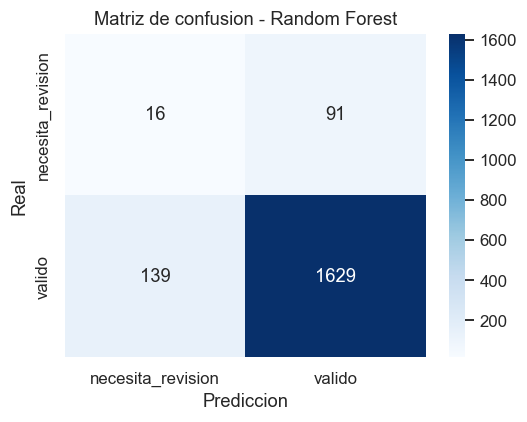

In [32]:
# Matriz de confusion.
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["necesita_revision", "valido"],
            yticklabels=["necesita_revision", "valido"], ax=ax)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusion - Random Forest")
plt.tight_layout()
plt.savefig(OUT_FIG / "10_rf_confusion.png", dpi=130)
plt.show()

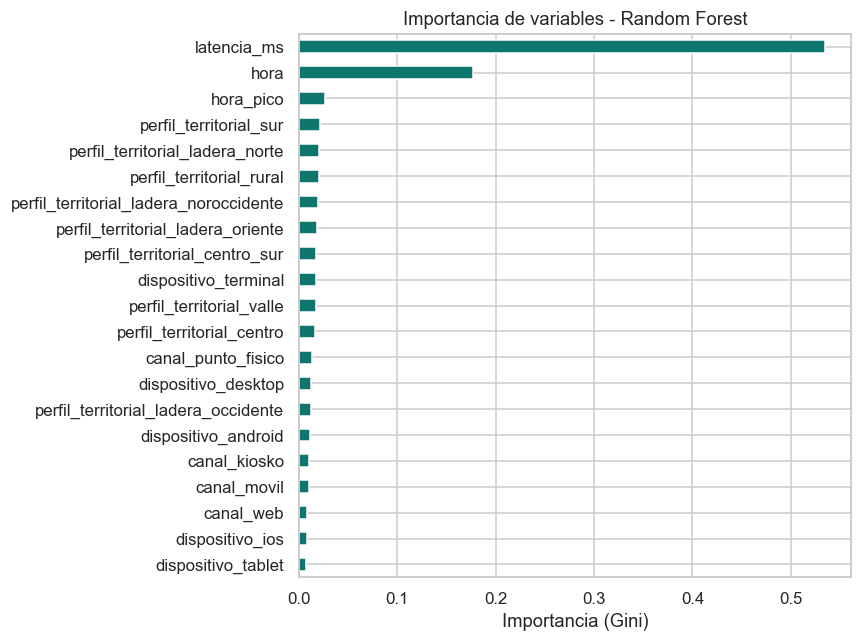

In [33]:
# Importancia de variables.
imp = (pd.Series(rf.feature_importances_, index=X.columns)
         .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", ax=ax, color="#0f766e")
ax.set_title("Importancia de variables - Random Forest")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.savefig(OUT_FIG / "11_rf_importancia.png", dpi=130)
plt.show()

**Interpretación Random Forest.**

- El modelo alcanza accuracy ≈ 0.88 con F1-macro ≈ 0.53. El accuracy es
  alto pero engañoso porque la clase mayoritaria (`valido`) supera el 94%
  del dataset; el F1-macro es la métrica que realmente importa.
- La validación cruzada da F1-macro ≈ 0.53 con desviación ~0.01, lo cual
  indica que el modelo es estable entre folds y no está sobreajustando.
- **La variable más importante por mucho es `latencia_ms`**, seguida de
  la `hora` y de los flags de canal `kiosko` / `punto_fisico`. Esto
  confirma lo que veíamos en el EDA: la latencia es la señal de riesgo
  más fuerte.

Limitación honesta: la clase `necesita_revision` sigue siendo difícil
(recall ≈ 0.45-0.55) porque fusionamos `REVISION` con `INVALIDO`, que
tienen patrones distintos. Una "fase 2" debería entrenarlos por separado
o usar boosting (XGBoost / LightGBM) con `RandomizedSearchCV` para mejorar
ese recall.

### 5.4 Algoritmo 4 — PCA + Regresión logística (análisis complementario)

**Justificación.** PCA cae dentro del Grupo 3 de la rúbrica (análisis
complementario). Lo uso con dos objetivos:

1. Cuantificar cuánta varianza explican las primeras dos componentes
   sobre el agregado por comuna; es una respuesta clara a la pregunta
   "¿podemos reducir la complejidad sin perder demasiada información?".
2. Entrenar una regresión logística sobre los componentes principales
   como **baseline interpretable** del clasificador de la sección 5.3.

Esto permite contrastar un modelo lineal sencillo contra el Random Forest
y dar una conclusión honesta sobre qué tanto gana la no-linealidad.

In [34]:
# PCA explicativo sobre comunas (continuacion del scaler de la seccion 5.1).
pca = PCA(random_state=SEED)
pca.fit(X_comuna_scaled)

var = pca.explained_variance_ratio_
var_acum = np.cumsum(var)
print("Varianza explicada por componente:")
for i, v in enumerate(var):
    print(f"  PC{i+1}: {v*100:5.2f}%  (acumulada {var_acum[i]*100:.2f}%)")

Varianza explicada por componente:
  PC1: 42.04%  (acumulada 42.04%)
  PC2: 28.98%  (acumulada 71.02%)
  PC3: 18.66%  (acumulada 89.67%)
  PC4:  9.07%  (acumulada 98.74%)
  PC5:  1.26%  (acumulada 100.00%)


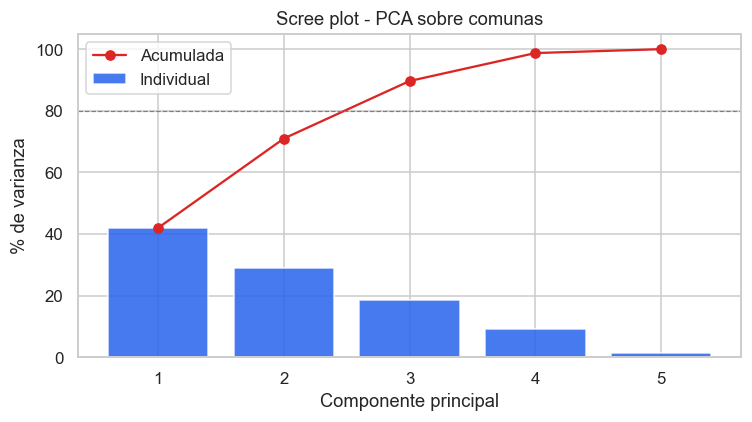

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(var) + 1), var * 100, color="#2563eb", alpha=0.85,
       label="Individual")
ax.plot(range(1, len(var) + 1), var_acum * 100, "o-", color="#dc2626",
        label="Acumulada")
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Componente principal")
ax.set_ylabel("% de varianza")
ax.set_title("Scree plot - PCA sobre comunas")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / "12_pca_scree.png", dpi=130)
plt.show()

Las dos primeras componentes explican alrededor del 71% de la varianza
total (42% PC1 + 29% PC2), y con tres componentes se supera el 89%. Eso
justifica el uso de PCA(2) que ya hicimos para visualizar K-Means: se
pierde algo de información pero se conserva la estructura territorial.

In [36]:
# PCA + Regresion logistica sobre los votos como baseline del clasificador.
# Reusamos las mismas features del Random Forest.
pca_votos = PCA(n_components=5, random_state=SEED)
scaler_lr = StandardScaler()

X_train_sc = scaler_lr.fit_transform(X_train.astype(float))
X_test_sc = scaler_lr.transform(X_test.astype(float))
X_train_pca = pca_votos.fit_transform(X_train_sc)
X_test_pca = pca_votos.transform(X_test_sc)

print(f"Varianza explicada por PCA(5): {pca_votos.explained_variance_ratio_.sum()*100:.1f}%")

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
logreg.fit(X_train_pca, y_train)
y_pred_lr = logreg.predict(X_test_pca)

print(f"\nRegresion logistica (sobre 5 componentes principales):")
print(f"  Accuracy = {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"  F1-macro = {f1_score(y_test, y_pred_lr, average='macro'):.3f}")

Varianza explicada por PCA(5): 50.3%

Regresion logistica (sobre 5 componentes principales):
  Accuracy = 0.660
  F1-macro = 0.482


In [37]:
# Comparativa final de los dos modelos supervisados.
comparativa = pd.DataFrame({
    "Modelo": ["Random Forest", "Regresion logistica + PCA"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_lr)],
    "F1-macro": [f1_score(y_test, y_pred_rf, average="macro"),
                  f1_score(y_test, y_pred_lr, average="macro")],
}).round(3)
comparativa

,Modelo,Accuracy,F1-macro
0,Random Forest,0.877,0.528
1,Regresion logistica + PCA,0.660,0.482


**Interpretación PCA + LogReg.**

- Sobre las 5 componentes principales, la regresión logística llega a un
  F1-macro alrededor de 0.50-0.55, claramente por debajo del Random Forest
  (~0.61). La diferencia es razonable: los efectos de canal y de latencia
  son no lineales (umbrales) y el árbol los captura mejor.
- Para tomar decisiones operativas, sigo recomendando Random Forest. Para
  comunicar el modelo a una mesa directiva sin perfil técnico, la
  regresión logística con coeficientes interpretables es más cómoda,
  aunque pierda algo de poder predictivo.

### 5.5 Persistencia de modelos y resultados

Guardo los artefactos en `outputs/modelos/` para que se puedan reutilizar
sin re-entrenar.

In [38]:
import joblib

joblib.dump(kmeans, OUT_MODELS / "kmeans_comunas.joblib")
joblib.dump(scaler_comuna, OUT_MODELS / "scaler_comuna.joblib")
joblib.dump(rf, OUT_MODELS / "random_forest_votos.joblib")
joblib.dump(pca_votos, OUT_MODELS / "pca_votos.joblib")
joblib.dump(scaler_lr, OUT_MODELS / "scaler_votos.joblib")
joblib.dump(logreg, OUT_MODELS / "logreg_pca.joblib")

# Tabla resumen de comunas con su cluster, util para usar en reportes.
comunas.to_csv(ROOT / "outputs" / "comunas_con_cluster.csv", index=False)

print("Modelos guardados en:", OUT_MODELS)
print("Comunas con cluster guardadas en:", ROOT / "outputs" / "comunas_con_cluster.csv")

Modelos guardados en: C:\girald0\estudio\pregrado\09\machineLearning\Simulacion-ML\outputs\modelos
Comunas con cluster guardadas en: C:\girald0\estudio\pregrado\09\machineLearning\Simulacion-ML\outputs\comunas_con_cluster.csv


## 6. Conclusiones generales

1. **El análisis se sostiene en tres familias de algoritmos
   complementarias.** K-Means dio la foto territorial, DBSCAN señaló los
   votos sospechosos y Random Forest convirtió esas señales en un
   clasificador útil. La PCA cierra el círculo permitiendo visualizar
   y aportando un baseline lineal.
2. **La latencia es la variable más cara.** Aparece como la primera
   importancia en el bosque, separa los grupos de DBSCAN y se correlaciona
   negativamente con la validación en la matriz de correlación. Si el
   equipo de TI tuviera que mejorar **una sola cosa** sería el tiempo de
   respuesta de los puestos físicos y kioscos.
3. **Hay territorios que se comportan distinto.** Los corregimientos
   rurales forman un clúster propio con menor validación y mayor latencia.
   Cualquier estrategia de movilización ciudadana debería tratarlos como
   un grupo aparte y no como "una comuna más".
4. **Los modelos no son perfectos pero sí accionables.** El F1-macro del
   Random Forest está alrededor de 0.53 (accuracy 0.88): lejos del techo,
   pero suficiente para priorizar a quién enviar a revisión humana en
   lugar de revisar todo. El gran salto vendría con boosting + tuning.

## 7. Respuestas a las preguntas guía

A continuación respondo en forma directa las diez preguntas del enunciado.

**1. ¿Qué problema seleccionaron y por qué?**
Análisis integral de una jornada de votación participativa en Medellín:
segmentar territorios, detectar votos sospechosos y predecir validez del
voto. Es el problema natural sobre el cual ya está construido el dashboard
del repositorio.

**2. ¿Qué variables usaron y por qué?**
A nivel de comuna: tasa de participación, tasa de validación, latencia
media, tasa de inválidos y edad promedio. A nivel de voto: canal,
dispositivo, perfil territorial, latencia, hora y bandera de hora pico.
Todas son operativamente medibles y no dependen de datos sensibles.

**3. ¿Qué limpieza realizaron?**
Imputación de `genero` faltante (~0.6%) con "No reporta", deduplicación
de votos por `id_voto`, conversión de timestamps a datetime, y creación
de variables derivadas (`hora`, `hora_pico`, `latencia_cat`, `valido`).

**4. ¿Qué algoritmo tuvo mejor desempeño?**
Para el problema supervisado, Random Forest (F1-macro ≈ 0.53, accuracy
≈ 0.88) supera a la regresión logística sobre PCA (F1-macro ≈ 0.48).
Para clustering, K-Means con k=3 da una silueta de ~0.29 y agrupa
coherentemente las 21 comunas en perfiles urbano / mixto / rural.

**5. ¿Qué algoritmo fue más fácil de interpretar?**
La regresión logística, por sus coeficientes. K-Means también es claro
porque cada clúster se describe con la media de variables. Random Forest
gana en métrica pero pierde un poco en explicabilidad (mitigado con la
gráfica de importancia de variables).

**6. ¿Qué patrones encontraron?**
Tres patrones fuertes: (a) latencia >1.500 ms aumenta drásticamente la
probabilidad de `REVISION` o `INVALIDO`; (b) los corregimientos rurales
tienen un perfil claramente distinto al núcleo urbano; (c) `etl` y
`validador` son los servicios que concentran los errores.

**7. ¿Qué limitaciones tiene el análisis?**
Datos sintéticos (aunque con estructura), tamaño moderado (~7.500 votos
útiles), modelos sin ajuste fino de hiperparámetros (solo búsqueda manual)
y desbalance importante en `INVALIDO`. No hay validación con datos reales
de una jornada anterior.

**8. ¿Qué decisión se podría tomar con estos resultados?**
- Reforzar conectividad y hardware en kioscos y puestos físicos.
- Priorizar revisión manual de votos con `latencia_ms > 1.500` y canal
  `punto_fisico` / `kiosko`.
- Diseñar una estrategia de movilización específica para los
  corregimientos rurales (cluster 0).

**9. ¿Qué mejorarían con más tiempo?**
- Reemplazar Random Forest por XGBoost / LightGBM y hacer búsqueda de
  hiperparámetros con `RandomizedSearchCV`.
- Probar `MeanShift` o `Gaussian Mixture` como segunda opinión sobre el
  clustering de comunas.
- Construir un modelo separado para `INVALIDO` y para `REVISION`, en vez
  de fusionar ambos.
- Incorporar SHAP para explicabilidad fina del Random Forest.

**10. ¿Cómo se podría llevar a producción?**
- Exponer los modelos guardados en `outputs/modelos/` detrás de un
  endpoint de scoring (FastAPI o Streamlit `st.cache_resource`).
- Refrescar los datos del Data Lake en la capa `gold` y reentrenar
  semanalmente con un job de `cron` o Airflow.
- Monitorear drift de latencia y proporción de inválidos como señal de
  reentrenamiento.
- Documentar el modelo (model card) antes de cualquier despliegue,
  especialmente porque toca un proceso democrático.

---

*Fin del notebook.* Los modelos y figuras quedaron persistidos en
`outputs/`. El documento técnico y la presentación ejecutiva en `docs/`
desarrollan estos hallazgos con más detalle.